In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [161]:
from src.data_generators import  generate_x_grid, generate_var3_3d, true_var3_3d_conditional_density
from src.rho_estimation import estimate_rho_grid
from src.r_bp import R_BP_density, kde_initial, fit_R_BP_marginals_until_t
from src.transform import X_to_U
from src.lag import lagged_k_U
from src.copula import fit_conditional_vines, estimate_patton_dynamic_gaussian_copula, dynamic_gaussian_copula_density, patton_next_rho
from src.conditional_density import conditional_marginal_all, build_u_tilde_data, conditional_marginal_pdf, conditional_marginal_cdf
from src.k_estimation import estimate_best_k

In [162]:
import importlib
import src.data_generators
import src.conditional_density
import src.copula
import src.k_estimation

importlib.reload(src.data_generators)
importlib.reload(src.copula)
importlib.reload(src.k_estimation)
importlib.reload(src.conditional_density)
importlib.reload(src.r_bp)
importlib.reload(src.rho_estimation)

<module 'src.rho_estimation' from '/Users/chaeyunkim/Desktop/code/src/rho_estimation.py'>

## **Generate data**

In [62]:
X, A1, A2, A3, Sigma = generate_var3_3d(T=1000, burn_in=300)

$$
\mathbf{X}=\begin{pmatrix}
X_1^{(1)} & X_1^{(2)} & X_1^{(3)} \\
\vdots & \vdots & \vdots \\
X_t^{(1)} & X_t^{(2)} & X_t^{(3)} \\
X_{t+1}^{(1)} & X_{t+1}^{(2)} & X_{t+1}^{(3)} \\
\vdots & \vdots & \vdots \\
X_{1000}^{(1)} & X_{1000}^{(2)} & X_{1000}^{(3)}
\end{pmatrix}
$$

In [5]:
X.shape

(1000, 3)

## **Estimate marginal pdf, cdf**

$$
\hat p_i^{(j)}(x) =\hat p_{i-1}^{(j)}(x)\left[(1-\alpha_i)+
\alpha_i c_{\hat\rho^{(j)}}\left(\hat P_{i-1}^{(j)}(x),\hat P_{i-1}^{(j)}(x_i^{(j)})\right)\right]
$$

$$
\hat P_i^{(j)}(x)=(1-\alpha_i)\hat P_{i-1}^{(j)}(x) + 
\alpha_i H_{\hat\rho^{(j)}}\left(\hat P_{i-1}^{(j)}(x),\hat P_{i-1}^{(j)}(x_i^{(j)})\right)
$$

$$
i = 1, \ldots, t
$$

In [200]:
t = 800  

X_train = X[:t]          # observed history: X_1,...,X_800
X_target = X[t:t+1]      # actual next observation: X_801

x_grids_t, p0_grids_t, P0_grids_t, rho_hats_t, p_grids_t, P_grids_t = fit_R_BP_marginals_until_t(X_train=X_train, rho_grid=rho_grid)

In [201]:
print(X_train.shape)
print(X_target.shape)

(800, 3)
(1, 3)


In [202]:
print(len(x_grids_t))
print(len(p_grids_t))
print(len(P_grids_t))

3
3
3


In [107]:
print(len(x_grids_t[0]))  # X^(1) grid
print(len(x_grids_t[1]))  # X^(2) grid
print(len(x_grids_t[2]))  # X^(3) grid

1000
1000
1000


Estimated R-BP parameters :

$$
\hat\rho^{(1)}=0.13,\qquad
\hat\rho^{(2)}=0.93,\qquad
\hat\rho^{(3)}=0.01
$$

In [108]:
rho_hats_t

[np.float64(0.13), np.float64(0.93), np.float64(0.01)]

**Estimated marginal PDF**

$$
\hat p_t^{(1)}(x),\qquad \hat p_t^{(2)}(x),\qquad \hat p_t^{(3)}(x)
$$


In [109]:
print(len(p_grids_t[0]))  # X^(1) estimated marginal PDF
print(len(p_grids_t[1]))  # X^(2) estimated marginal PDF
print(len(p_grids_t[2]))  # X^(3) estimated marginal PDF

1000
1000
1000


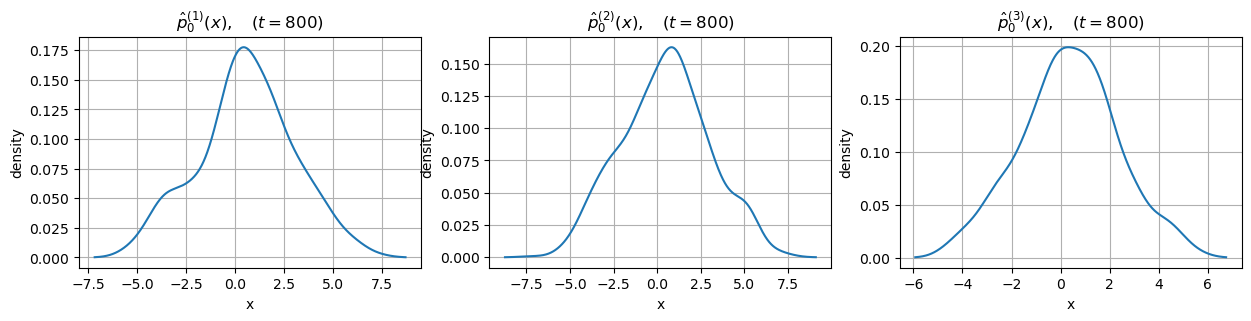

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for j in range(3):
    axes[j].plot(x_grids_t[j], p0_grids_t[j])
    axes[j].set_title(rf"$\hat p_{{0}}^{{({j+1})}}(x),\quad (t=800)$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("density")
    axes[j].grid(True)

plt.show()

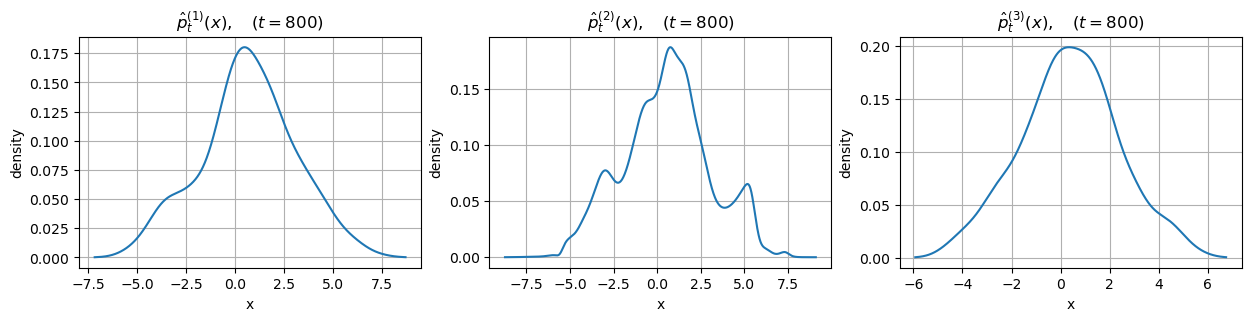

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for j in range(3):
    axes[j].plot(x_grids_t[j], p_grids_t[j])
    axes[j].set_title(rf"$\hat p_{{t}}^{{({j+1})}}(x),\quad (t=800)$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("density")
    axes[j].grid(True)


plt.show()

**Estimated marginal CDF**

$$
\hat P_t^{(1)}(x),\qquad \hat P_t^{(2)}(x),\qquad \hat P_t^{(3)}(x)
$$


In [112]:
print(len(P_grids[0]))  # X^(1) estimated marginal CDF
print(len(P_grids[1]))  # X^(2) estimated marginal CDF
print(len(P_grids[2]))  # X^(3) estimated marginal CDF

1000
1000
1000


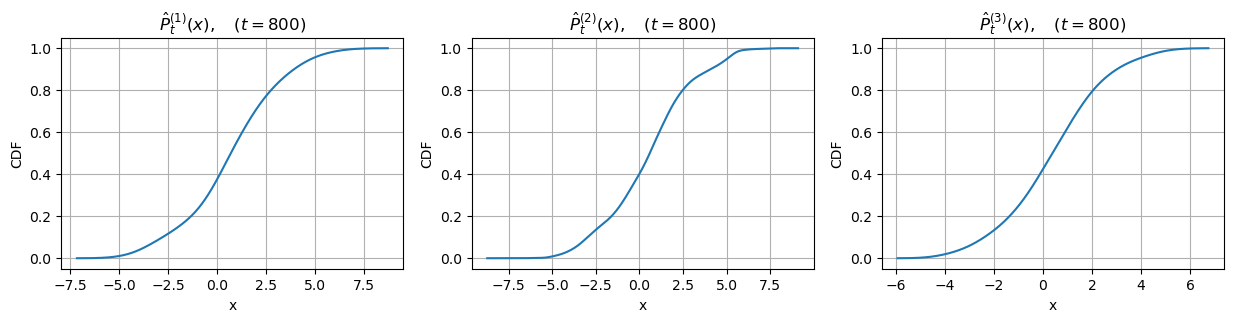

In [113]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for j in range(3):
    axes[j].plot(x_grids_t[j], P_grids_t[j])
    axes[j].set_title(rf"$\hat P_{{t}}^{{({j+1})}}(x),\quad (t=800)$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("CDF")
    axes[j].grid(True)

plt.show()

$$
U_i^{(j)}=\hat P_t^{(j)}\left(X_i^{(j)}\right) \in[0,1],
\qquad i=1,\ldots,t,\quad j=1,2,3.
$$

<br>

$$
\mathbf{U}
= \begin{pmatrix}
\hat P_t^{(1)}(X_1^{(1)}) & \hat P_t^{(2)}(X_1^{(2)}) & \hat P_t^{(3)}(X_1^{(3)}) \\
\vdots & \vdots & \vdots \\
\hat P_t^{(1)}(X_{t}^{(1)}) & \hat P_t^{(2)}(X_{t}^{(2)}) & \hat P_t^{(3)}(X_{t}^{(3)})
\end{pmatrix}
= \begin{pmatrix}
U_1^{(1)} & U_1^{(2)} & U_1^{(3)} \\
\vdots & \vdots & \vdots \\
U_{t}^{(1)} & U_{t}^{(2)} & U_{t}^{(3)}
\end{pmatrix}
$$

In [114]:
U_train_t = X_to_U(X=X_train, x_grids=x_grids_t, P_grids=P_grids_t)
U_target_t = X_to_U(X=X_next, x_grids=x_grids_t, P_grids=P_grids_t)

In [116]:
print(U_train_t.shape)
print(U_target_t.shape)
U_train_t.min(), U_train_t.max()

(800, 3)
(1, 3)


(np.float64(0.00027552180320283685), np.float64(0.9995918357956601))

## **Conditional marginal density**

In [125]:
k = 3

U_condition_train, U_target_train = lagged_k_U(U_train_t, k)

$$
U_{\text{condition\_train}}
=\begin{pmatrix}
U_3^{(1)} & U_3^{(2)} & U_3^{(3)} \qquad
&
U_2^{(1)} & U_2^{(2)} & U_2^{(3)}\qquad
&
U_1^{(1)} & U_1^{(2)} & U_1^{(3)}
\\
U_4^{(1)} & U_4^{(2)} & U_4^{(3)}\qquad
&
U_3^{(1)} & U_3^{(2)} & U_3^{(3)}\qquad
&
U_2^{(1)} & U_2^{(2)} & U_2^{(3)}
\\
U_5^{(1)} & U_5^{(2)} & U_5^{(3)}\qquad
&
U_4^{(1)} & U_4^{(2)} & U_4^{(3)}\qquad
&
U_3^{(1)} & U_3^{(2)} & U_3^{(3)}
\\
\vdots & \vdots & \vdots
&
\vdots & \vdots & \vdots
&
\vdots & \vdots & \vdots
\\
U_{798}^{(1)} & U_{798}^{(2)} & U_{798}^{(3)}
&
U_{797}^{(1)} & U_{797}^{(2)} & U_{797}^{(3)}
&
U_{796}^{(1)} & U_{796}^{(2)} & U_{796}^{(3)}
\\
U_{799}^{(1)} & U_{799}^{(2)} & U_{799}^{(3)}
&
U_{798}^{(1)} & U_{798}^{(2)} & U_{798}^{(3)}
&
U_{797}^{(1)} & U_{797}^{(2)} & U_{797}^{(3)}
\end{pmatrix}
$$

<br>

$$
U_{\text{target\_train}}
=\begin{pmatrix}
U_4^{(1)} & U_4^{(2)} & U_4^{(3)}
\\
U_5^{(1)} & U_5^{(2)} & U_5^{(3)}
\\
U_6^{(1)} & U_6^{(2)} & U_6^{(3)}
\\
\vdots & \vdots & \vdots
\\
U_{799}^{(1)} & U_{799}^{(2)} & U_{799}^{(3)}
\\
U_{800}^{(1)} & U_{800}^{(2)} & U_{800}^{(3)}
\end{pmatrix}.
$$

In [204]:
U_condition_train

array([[0.37782223, 0.24528454, 0.18288471, ..., 0.59543306, 0.31846944,
        0.46691142],
       [0.24528454, 0.18288471, 0.21384373, ..., 0.31846944, 0.46691142,
        0.29057562],
       [0.18288471, 0.21384373, 0.17673284, ..., 0.46691142, 0.29057562,
        0.38093856],
       ...,
       [0.96571485, 0.95737736, 0.95196893, ..., 0.94535042, 0.92790808,
        0.92037108],
       [0.95737736, 0.95196893, 0.88096649, ..., 0.92790808, 0.92037108,
        0.9184261 ],
       [0.95196893, 0.88096649, 0.84175049, ..., 0.92037108, 0.9184261 ,
        0.91481314]])

In [203]:
U_target_train

array([[0.21384373, 0.0652466 , 0.29057562],
       [0.17673284, 0.17180803, 0.38093856],
       [0.2773314 , 0.70524711, 0.15805625],
       ...,
       [0.88096649, 0.94981638, 0.9184261 ],
       [0.84175049, 0.91735094, 0.91481314],
       [0.95119447, 0.94285906, 0.95003283]])

In [126]:
print(U_condition_train.shape)
print(U_target_train.shape)

(797, 9)
(797, 3)



the most recent three observations are used for predicting $U_{801}$ 

**u_condition_pred**

$$
\begin{pmatrix}
U_{798}^{(1)} & U_{798}^{(2)} & U_{798}^{(3)} \\
U_{799}^{(1)} & U_{799}^{(2)} & U_{799}^{(3)} \\
U_{800}^{(1)} & U_{800}^{(2)} & U_{800}^{(3)}
\end{pmatrix}
$$


In [ ]:
u_condition_pred = U_train_t[-k:, :].T.reshape(-1)

**vine copula**

In [122]:
vines_t = fit_conditional_vines(U_condition=U_condition_train, U_target=U_target_train)

$$
\text{vine}_1\quad:\quad \hat c_{vine}^{(1)}
\left(U_{t+1}^{(1)}, U_t, U_{t-1}, U_{t-2}\right)
$$

$$
\text{vine}_2\quad:\quad\hat c_{vine}^{(2)}
\left(U_{t+1}^{(2)}, U_t, U_{t-1}, U_{t-2}\right)
$$

$$
\text{vine}_3\quad:\quad \hat c_{vine}^{(3)}
\left(U_{t+1}^{(3)}, U_t, U_{t-1}, U_{t-2}\right)
$$

In [124]:
vines_t

[<pyvinecopulib.Vinecop> Vinecop model with 10 variables
 tree edge conditioned variables  conditioning variables var_types       family rotation parameters  df  tau 
    1    1                  7, 4                              c, c     Gaussian        0       0.86 1.0 0.67 
    1    2                  5, 2                              c, c     Gaussian        0       0.86 1.0 0.66 
    1    3                  2, 3                              c, c     Gaussian        0       0.89 1.0 0.70 
    1    4                  1, 4                              c, c     Gaussian        0       0.89 1.0 0.70 
    1    5                  6, 3                              c, c     Gaussian        0       0.86 1.0 0.66 
    1    6                  3, 4                              c, c     Gaussian        0       0.89 1.0 0.70 
    1    7                  8, 9                              c, c     Gaussian        0       0.88 1.0 0.68 
    1    8                 4, 10                              c

spline density 

**conditional marginal PDF,CDF curves**

conditional marginal PDF curve :
$
\widehat p_{\mathrm{cond}}^{(j)}
\left(y \mid \mathcal F_t\right)
=\widehat p^{(j)}(y)\cdot\displaystyle\frac{\widehat c_{vine}^{(j)}\left(\widehat P^{(j)}(y),u_{\mathrm{condition}}\right)
}{
\displaystyle\int_0^1\widehat c_{vine}^{(j)}\left(s,u_{\mathrm{condition}}\right)\,ds}
$

<br>

$$
p_{\mathrm{cond\_curves}}[j]
=\left(
\hat p_{\mathrm{cond}}^{(j)}\left(y_1^{(j)} \mid \mathcal F_t\right),\hat p_{\mathrm{cond}}^{(j)}
\left(y_2^{(j)} \mid \mathcal F_t\right),\ldots,\hat p_{\mathrm{cond}}^{(j)}
\left(y_m^{(j)} \mid \mathcal F_t\right)\right)
$$


<br>

conditional marginal CDF curve : $
\widehat P_{\mathrm{cond}}^{(j)}
\left(y \mid \mathcal F_t\right)
=\frac{\displaystyle\int_0^{\widehat P^{(j)}(y)}\widehat c_{vine}^{(j)}\left(s,u_{\mathrm{condition}}\right)\,ds
}{
\displaystyle\int_0^1\widehat c_{vine}^{(j)}\left(s,u_{\mathrm{condition}}\right)\,ds}
$

<br>

$$
P_{\mathrm{cond\_curves}}[j]
=\left(\hat P_{\mathrm{cond}}^{(j)}
\left(y_1^{(j)} \mid \mathcal F_t\right),\hat P_{\mathrm{cond}}^{(j)}
\left(y_2^{(j)} \mid \mathcal F_t\right),\ldots,\hat P_{\mathrm{cond}}^{(j)}
\left(y_m^{(j)} \mid \mathcal F_t\right)\right)
$$

In [193]:
p_cond_curves = []
P_cond_curves = []

for j in range(3):

    y_grid_j = x_grids_t[j]

    # conditional marginal PDF curve
    p_cond_curve_j = []

    for y_val in y_grid_j:

        p_cond_val = conditional_marginal_pdf(y_j=y_val, vine_j=vines_t[j], u_condition=u_condition_pred, 
                                              x_grid_j=x_grids_t[j], p_grid_j=p_grids_t[j], P_grid_j=P_grids_t[j])

        p_cond_curve_j.append(p_cond_val)

    p_cond_curve_j = np.array(p_cond_curve_j)


    # conditional marginal CDF curve
    P_cond_curve_j = []

    for y_val in y_grid_j:

        P_cond_val = conditional_marginal_cdf(y_j=y_val, vine_j=vines_t[j], u_condition=u_condition_pred,
                                              x_grid_j=x_grids_t[j], P_grid_j=P_grids_t[j])

        P_cond_curve_j.append(P_cond_val)

    P_cond_curve_j = np.array(P_cond_curve_j)


    p_cond_curves.append(p_cond_curve_j)
    P_cond_curves.append(P_cond_curve_j)

In [192]:
len(p_cond_curves)

3

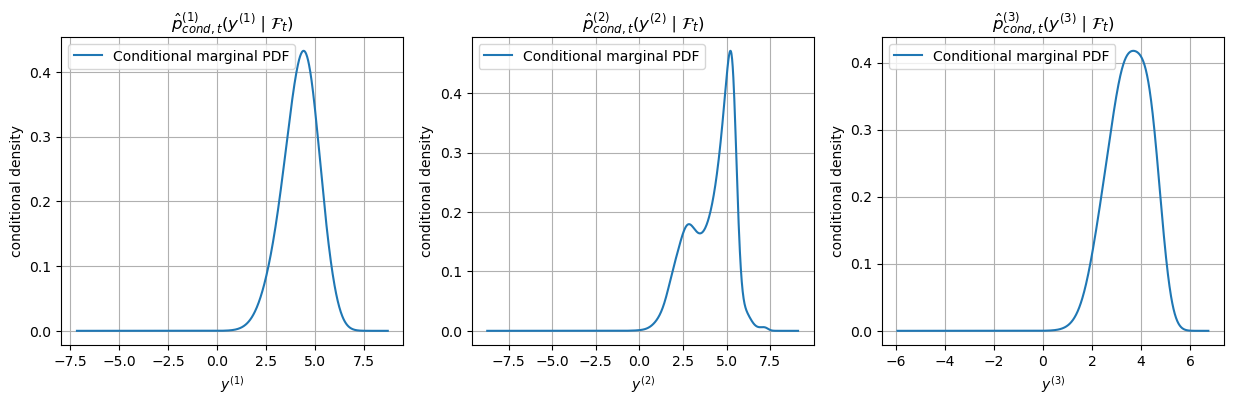

In [194]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j in range(3):

    axes[j].plot(
        x_grids_t[j],
        p_cond_curves[j],
        label="Conditional marginal PDF"
    )

    axes[j].set_title(
        rf"$\hat p_{{cond}}^{{({j+1})}}(y^{{({j+1})}}\mid \mathcal{{F}}_t)$"
    )
    axes[j].set_xlabel(rf"$y^{{({j+1})}}$")
    axes[j].set_ylabel("conditional density")
    axes[j].legend()
    axes[j].grid(True)

plt.show()

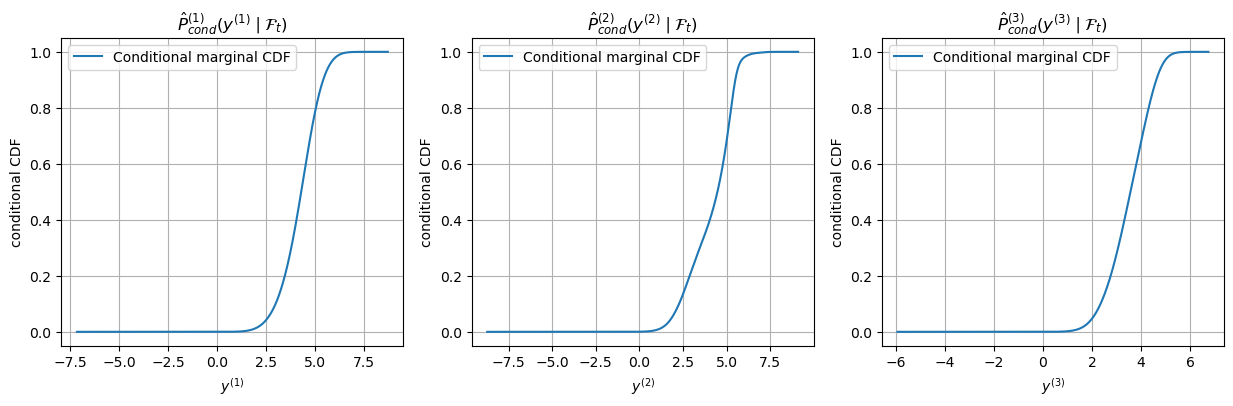

In [197]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j in range(3):

    axes[j].plot(
        x_grids_t[j],
        P_cond_curves[j],
        label="Conditional marginal CDF"
    )

    axes[j].set_title(
        rf"$\hat P_{{cond}}^{{({j+1})}}(y^{{({j+1})}}\mid \mathcal{{F}}_t)$"
    )
    axes[j].set_xlabel(rf"$y^{{({j+1})}}$")
    axes[j].set_ylabel("conditional CDF")
    axes[j].legend()
    axes[j].grid(True)


plt.show()

## **Time-varying copula**

In [ ]:
mh sampling 

## **Conditional joint density**